### Importing Libraries

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

import torch.optim as optim

import os

from PIL import Image, ImageOps

import random

#import any other library you need below this line
import cv2
from torchvision.transforms.functional import center_crop as CenterCrop

### Loading data

Upload the data in zip format to Colab. Then run the cell below.

In [21]:
!unzip data.zip

'unzip' is not recognized as an internal or external command,
operable program or batch file.


### Defining the Dataset Class

In [22]:
def histogram_equalization(img):
    img = np.array(img)
    equalized_img = cv2.equalizeHist(img)
    return Image.fromarray(equalized_img)

class Cell_data(Dataset):
    def __init__(self, data_dir, size, train='True', train_test_split=0.8, augment_data=True):
        ##########################inputs##################################
        # data_dir(string) - directory of the data#########################
        # size(int) - size of the images you want to use###################
        # train(boolean) - train data or test data#########################
        # train_test_split(float) - the portion of the data for training###
        # augment_data(boolean) - use data augmentation or not#############
        super(Cell_data, self).__init__()
        # initialize the data class
        self.data_dir = data_dir
        self.size = size
        self.train = train
        self.train_test_split = train_test_split
        self.augment_data = augment_data

        self.image_paths = sorted(
            [os.path.join(data_dir, 'scans', file_name) for file_name in os.listdir(os.path.join(data_dir, 'scans'))])
        self.mask_paths = sorted(
            [os.path.join(data_dir, 'labels', file_name) for file_name in os.listdir(os.path.join(data_dir, 'labels'))])

        split_idx = int(len(self.image_paths) * train_test_split)

        if self.train:
            self.image_paths = self.image_paths[:split_idx]
            self.mask_paths = self.mask_paths[:split_idx]
        else:
            self.image_paths = self.image_paths[split_idx:]
            self.mask_paths = self.mask_paths[split_idx:]

        # Define basic transformations (resize and normalize)
        self.image_transform = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor()
        ])

        self.label_transform = transforms.Compose([
            transforms.Resize((size, size)),
            lambda img: torch.from_numpy(np.array(img)).unsqueeze(0)
        ])

    def __getitem__(self, idx):
        # load image and mask from index idx of your data
        img_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]

        image = Image.open(img_path).convert('L')  # Grayscale image (1 channel)
        mask = Image.open(mask_path)

        # apply histogram equalization for data balancing
        image = histogram_equalization(image)

        # Apply basic transformations
        image = self.image_transform(image)
        mask = self.label_transform(mask)

        # data augmentation part
        if self.augment_data and self.train:
            augment_mode = np.random.randint(0, 6)
            if augment_mode == 0:
                # flip image vertically
                image = TF.vflip(image)
                mask = TF.vflip(mask)
            elif augment_mode == 1:
                # flip image horizontally
                image = TF.hflip(image)
                mask = TF.hflip(mask)
            elif augment_mode == 2:
                # zoom image
                crop_transform = transforms.Compose([
                    transforms.CenterCrop(int(self.size * 0.8)),
                    transforms.Resize((self.size, self.size))
                ])
                image = crop_transform(image)
                mask = crop_transform(mask)
            elif augment_mode == 3:
                # rotate image
                angle = random.choice([90, 180, 270])
                image = TF.rotate(image, angle)
                mask = TF.rotate(mask, angle)
            elif augment_mode == 4:
                # Gamma correction
                gamma = random.uniform(0.8, 1.2)
                image = TF.adjust_gamma(image, gamma=gamma)
            else:
                # Non-rigid transformation
                elastic_transformer = transforms.ElasticTransform(alpha=10.0, sigma=10.0)
                image = elastic_transformer(image)
                mask = elastic_transformer(mask)

        # return image and mask in tensors
        return image.squeeze(0), mask.squeeze(0)

    def __len__(self):
        return len(self.image_paths)

### Define the Model
1. Define the Convolution blocks
2. Define the down path
3. Define the up path
4. combine the down and up path to get the final model

In [23]:
class twoConvBlock(nn.Module):
  def __init__(self, in_channels, out_channels):
    super(twoConvBlock, self).__init__()
    #initialize the block
    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=0)
    self.relu = nn.ReLU(inplace=True)
    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=0)
    self.bn = nn.BatchNorm2d(out_channels)
    self.dropout = nn.Dropout(p=0.2)

  def forward(self, x):
    #implement the forward path
    x = self.relu(self.conv1(x))
    x = self.relu(self.bn(self.conv2(x)))
    x = self.dropout(x)
    return x

class downStep(nn.Module):
  def __init__(self, in_channels, out_channels):
    super(downStep, self).__init__()
    #initialize the down path
    self.conv_block = twoConvBlock(in_channels, out_channels)
    self.max_pool = nn.MaxPool2d(kernel_size=2, stride=2)

  def forward(self, x):
    x = self.conv_block(x)
    x_down_sampled = self.max_pool(x)
    return x, x_down_sampled

class upStep(nn.Module):
  def __init__(self, in_channels, out_channels):
    super(upStep, self).__init__()
    #initialize the up path
    self.up_conv = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
    self.conv_block = twoConvBlock(in_channels, out_channels)


  def forward(self, x, skip_connection):
    #implement the forward path
    x = self.up_conv(x)
    target_size = (x.size(2), x.size(3))
    skip_connection = CenterCrop(skip_connection, output_size=target_size)
    # skip_connection = self.crop_tensor(skip_connection, x)
    x = torch.cat([x, skip_connection], dim=1)
    x = self.conv_block(x)
    return x


class UNet(nn.Module):
  def __init__(self, in_channels=1, out_channels=2):
      super(UNet, self).__init__()
      self.down1 = downStep(in_channels, 64)
      self.down2 = downStep(64, 128)
      self.down3 = downStep(128, 256)
      self.down4 = downStep(256, 512)

      self.bottleneck = twoConvBlock(512, 1024)

      self.up1 = upStep(1024, 512)
      self.up2 = upStep(512, 256)
      self.up3 = upStep(256, 128)
      self.up4 = upStep(128, 64)

      self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

  def forward(self, x):
      x1, x_down1 = self.down1(x)
      x2, x_down2 = self.down2(x_down1)
      x3, x_down3 = self.down3(x_down2)
      x4, x_down4 = self.down4(x_down3)

      x_bottleneck = self.bottleneck(x_down4)

      x = self.up1(x_bottleneck, x4)
      x = self.up2(x, x3)
      x = self.up3(x, x2)
      x = self.up4(x, x1)

      # Final output layer (to match output channels)
      x = self.final_conv(x)

      return x


### Training

In [24]:
#Paramteres

#learning rate
lr = 1e-5

#number of training epochs
epoch_n = 25

#input image-mask size
image_size = 572
#root directory of project
root_dir = os.path.dirname(os.getcwd())

#training batch size
batch_size = 2

Adam_weight_decay = 1e-5
SGD_weight_decay = 1e-4
# Initialize Wandb
wandb.init(
    project="CMPT742_A2",
    config={
        "learning_rate": lr,
        "epochs": epoch_n,
        "batch_size": batch_size,
        "image_size": image_size,
        "Adam_weight_decay": Adam_weight_decay,
        "SGD_weight_decay": SGD_weight_decay,
    }
)

# use checkpoint model for training
load = False
# use GPU for training
gpu = True

data_dir = os.path.join(root_dir, 'data/cells')

trainset = Cell_data(data_dir=data_dir, size=image_size)
trainloader = DataLoader(trainset, batch_size=4, shuffle=True)

testset = Cell_data(data_dir=data_dir, size=image_size, train=False)
testloader = DataLoader(testset, batch_size=4)

device = torch.device('cuda:0' if gpu else 'cpu')

model = UNet().to('cuda:0').to(device)

# Initialize logging
wandb.watch(model, log="all")

if load:
    print('loading model')
    model.load_state_dict(torch.load('checkpoint.pt'))

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=Adam_weight_decay)
scheduler = StepLR(optimizer, step_size=10, gamma=0.9)

for e in range(epoch_n):
    if e > 10:
        optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=SGD_weight_decay)
        scheduler = StepLR(optimizer, step_size=10, gamma=0.9)

    epoch_loss = 0
    model.train()
    for i, data in enumerate(trainloader):
        image, label = data

        image = image.unsqueeze(1).to(device)
        label = label.long().to(device)

        pred = model(image)

        crop_x = (label.shape[1] - pred.shape[2]) // 2
        crop_y = (label.shape[2] - pred.shape[3]) // 2

        label = label[:, crop_x: label.shape[1] - crop_x, crop_y: label.shape[2] - crop_y]

        loss = criterion(pred, label)

        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

        epoch_loss += loss.item()

        print('batch %d --- Loss: %.4f' % (i, loss.item() / batch_size))

    # Step the scheduler
    scheduler.step()

    print('Epoch %d / %d --- Loss: %.4f' % (e + 1, epoch_n, epoch_loss / trainset.__len__()))

    torch.save(model.state_dict(), 'checkpoint.pt')

    # Log training loss to W&B
    wandb.log({"Epoch_Loss": epoch_loss / trainset.__len__()})

    model.eval()

    total = 0
    correct = 0
    total_loss = 0

    with torch.no_grad():
        for i, data in enumerate(testloader):
            image, label = data

            image = image.unsqueeze(1).to(device)
            label = label.long().to(device)

            pred = model(image)
            crop_x = (label.shape[1] - pred.shape[2]) // 2
            crop_y = (label.shape[2] - pred.shape[3]) // 2

            label = label[:, crop_x: label.shape[1] - crop_x, crop_y: label.shape[2] - crop_y]

            loss = criterion(pred, label)
            total_loss += loss.item()

            _, pred_labels = torch.max(pred, dim=1)

            total += label.shape[0] * label.shape[1] * label.shape[2]
            correct += (pred_labels == label).sum().item()

        print('Accuracy: %.4f ---- Loss: %.4f' % (correct / total, total_loss / testset.__len__()))

        wandb.log({
            "accuracy": correct / total,
            "validation_loss": total_loss / testset.__len__()
        })

UNet(
  (down1): downStep(
    (conv_block): twoConvBlock(
      (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1))
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (max_pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (down2): downStep(
    (conv_block): twoConvBlock(
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1))
      (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (max_pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (down3): downStep(
    (conv_block): twoConvBlock(
      (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
      (relu): ReLU(inplace=True)
      (conv2): Conv2

### Testing and Visualization

In [26]:
#testing and visualization

model.eval()

output_masks = []
output_labels = []

with torch.no_grad():
    for i in range(testset.__len__()):
        image, labels = testset.__getitem__(i)

        input_image = image.unsqueeze(0).unsqueeze(0).to(device)
        pred = model(input_image)

        output_mask = torch.max(pred, dim=1)[1].cpu().squeeze(0).numpy()

        crop_x = (labels.shape[0] - output_mask.shape[0]) // 2
        crop_y = (labels.shape[1] - output_mask.shape[1]) // 2
        labels = labels[crop_x: labels.shape[0] - crop_x, crop_y: labels.shape[1] - crop_y].numpy()

        output_masks.append(output_mask)
        output_labels.append(labels)

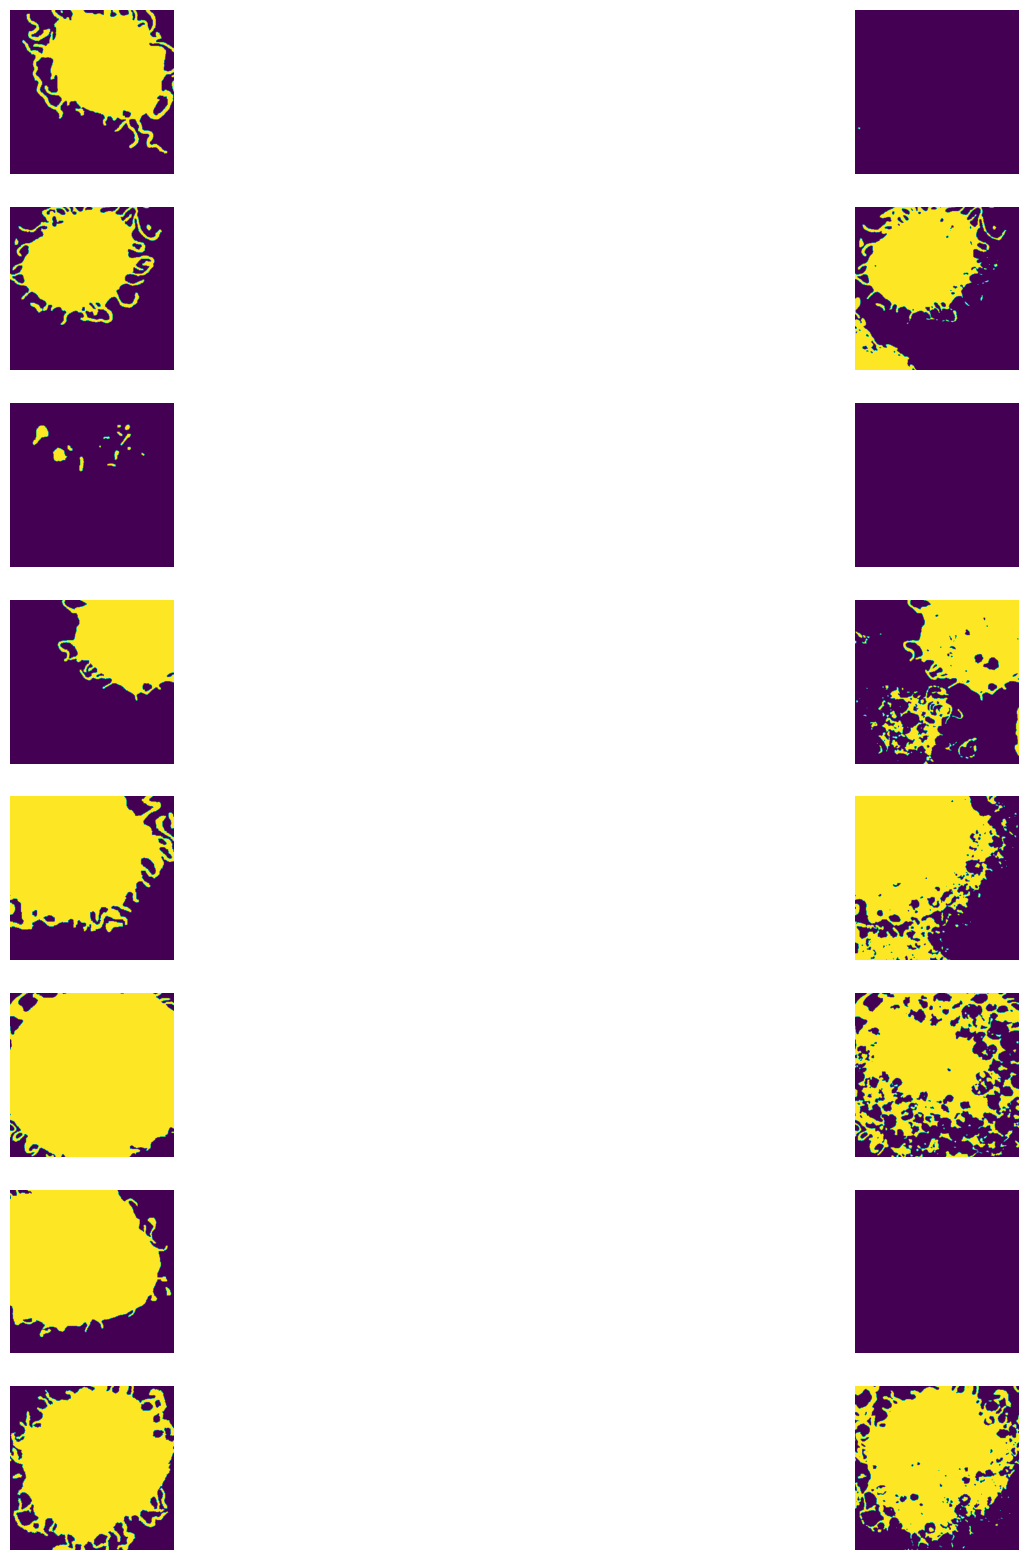

In [27]:
fig, axes = plt.subplots(testset.__len__(), 2, figsize = (20, 20))

for i in range(testset.__len__()):
  axes[i, 0].imshow(output_labels[i])
  axes[i, 0].axis('off')
  axes[i, 1].imshow(output_masks[i])
  axes[i, 1].axis('off')